In [1]:
from new_mclimate import MClimate
import matplotlib.pyplot as plt
import seaborn as sns
from gefsv12_retro_kerchunk import utils
import numpy as np
sns.set_theme(style="darkgrid", palette="deep",font_scale=1.3)

In [2]:
client = utils.start_dask_cluster(
    n_workers=2, threads_per_worker=4, memory_limit="4GiB"
)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:8787/status,
Dashboard: http://127.0.0.1:8787/status,Workers: 2
Total threads: 8,Total memory: 8.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:49366,Workers: 2
Dashboard: http://127.0.0.1:8787/status,Total threads: 8
Started: Just now,Total memory: 8.00 GiB
Comm: tcp://127.0.0.1:49374,Total threads: 4
Dashboard: http://127.0.0.1:49376/status,Memory: 4.00 GiB
Nanny: tcp://127.0.0.1:49369,


In [3]:
mc = MClimate()

gefs_r, gefs_l = mc.run_spread_mclimate()

/Users/taylor/code/kerchunk/kerchunk/combine.py:380: UserWarning: Concatenated coordinate 'step' contains less than expectednumber of values across the datasets: [3]
  warnings.warn(


File s3://noaa-gefs-pds/gefs.20241106/18/atmos/pgrb2sp25/gespr.t18z.pgrb2s.0p25.f003 written to /var/folders/vz/txd62qzn76g9f6cxg_8_76cw0000gn/T/tmplw2_gejogefs_rt_spr.json


/Users/taylor/code/kerchunk/kerchunk/combine.py:380: UserWarning: Concatenated coordinate 'valid_time' contains less than expectednumber of values across the datasets: [1730926800]
  warnings.warn(


File s3://noaa-gefs-pds/gefs.20241106/18/atmos/pgrb2sp25/geavg.t18z.pgrb2s.0p25.f003 written to /var/folders/vz/txd62qzn76g9f6cxg_8_76cw0000gn/T/tmplw2_gejogefs_rt_avg.json


/Users/taylor/code/kerchunk/kerchunk/combine.py:380: UserWarning: Concatenated coordinate 'valid_time' contains less than expectednumber of values across the datasets: [1730926800]
  warnings.warn(


In [4]:
gefs_r_std = gefs_r.std(dim="number")
gefs_r_mean = gefs_r.mean(dim="number")

In [ ]:
def combine_fcast_and_mcli(fcast, mcli):
    big_ds = xr.concat([mcli['Pressure'].drop('timestr'),fcast['Pressure'].expand_dims('time')],dim='time')
    percentile = bottleneck.rankdata(big_ds,axis=0)/len(big_ds['time'])
    return percentile

In [5]:
bins = np.arange(0,200,4)


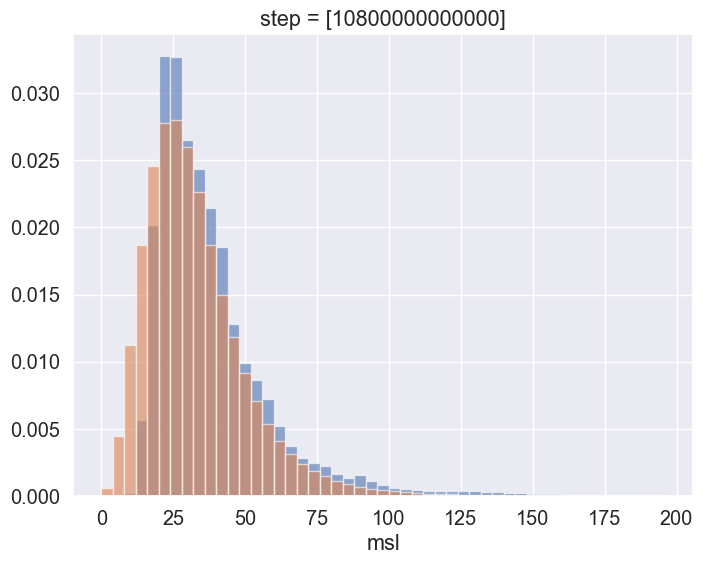

In [ ]:
fig, ax = plt.subplots(figsize=(8,6))
gefs_l.gespr['prmsl'].plot.hist(bins=bins,ax=ax,alpha=0.6,density=True,label='GEFS-L')
gefs_r_std['msl'].plot.hist(bins=bins, ax=ax, alpha=0.6, density=True, label='GEFS-R')
plt.show()

In [6]:
quantiles = np.linspace(0, 1, 100)
gefs_r_quantiles = np.quantile(gefs_r_std['msl'], quantiles)
gefs_l_quantiles = np.quantile(gefs_l.gespr['prmsl'], quantiles)

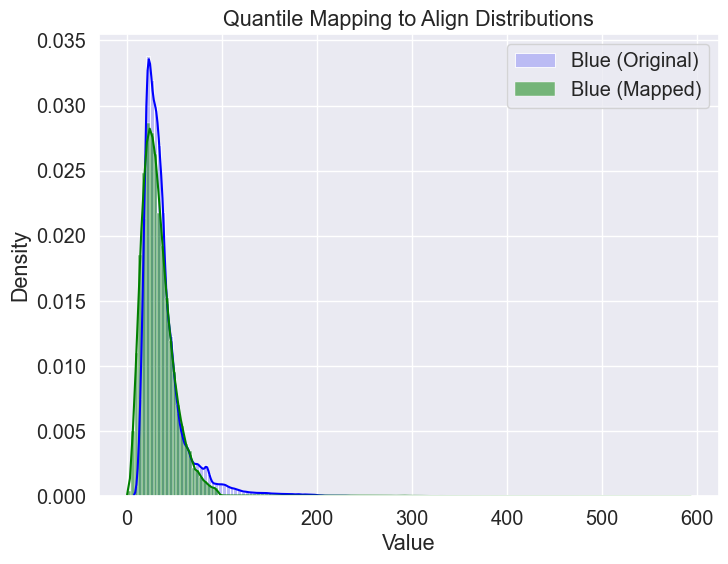

In [10]:
# Step 2: Map blue data to orange distribution using quantiles
mapped_gefs_l_data = np.interp(gefs_l.gespr['prmsl'].values.flatten(), gefs_l_quantiles, gefs_r_quantiles)
fig, ax = plt.subplots(figsize=(8,6))
# Plot the original and mapped distributions
# sns.histplot(gefs_r_std['msl'].values.flatten(), ax=ax, bins=bins, kde=True, color="orange", stat="density", label="Orange (Target)")
sns.histplot(gefs_l.gespr['prmsl'].values.flatten(), ax=ax, bins=bins, kde=True, color="blue", alpha=0.2, stat="density", label="Blue (Original)")
sns.histplot(mapped_gefs_l_data, ax=ax, bins=bins, kde=True, color="green", alpha=0.5, stat="density", label="Blue (Mapped)")

plt.legend()
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Quantile Mapping to Align Distributions")
plt.show()


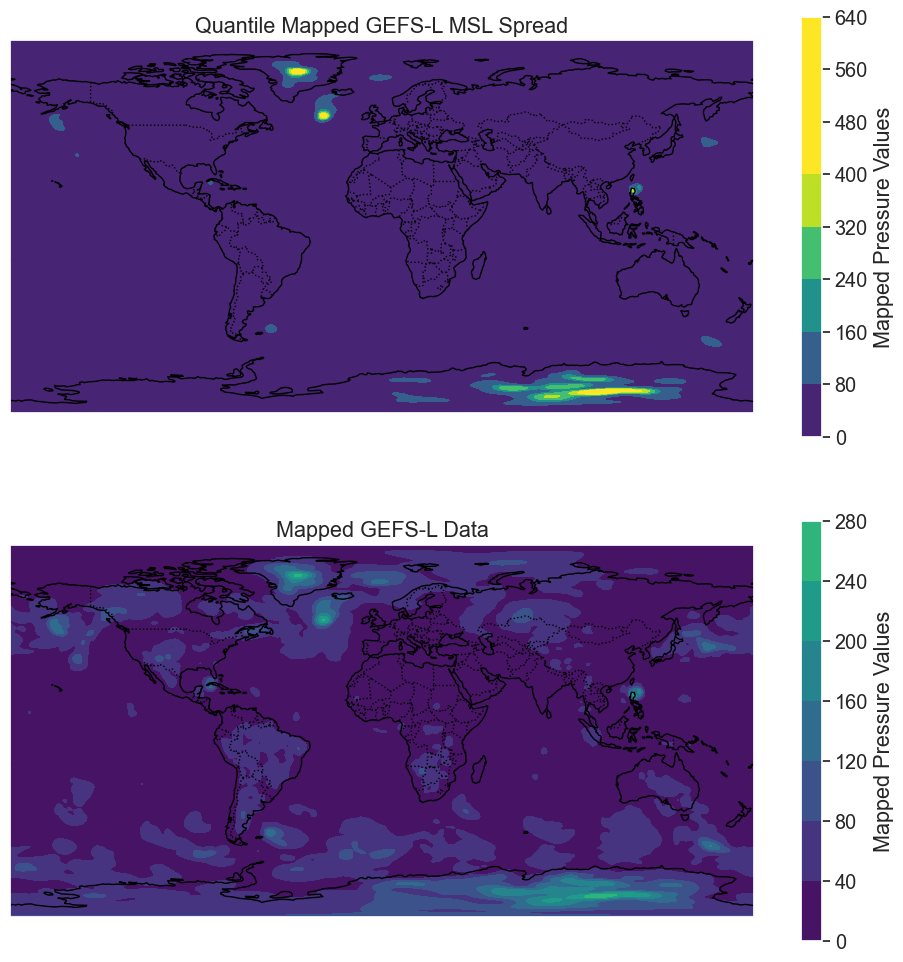

In [ ]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Reshape the mapped data to the original shape
reshaped_data = mapped_gefs_l_data.reshape(gefs_l.gespr['prmsl'].shape)

# Create a figure and axis with Cartopy projection
fig, ax = plt.subplots(2,1,figsize=(12, 12), subplot_kw={'projection': ccrs.PlateCarree()})

# Add coastlines and borders for better visualization
ax[0].coastlines()
ax[0].add_feature(cfeature.BORDERS, linestyle=':')
# Add coastlines and borders for better visualization
ax[1].coastlines()
ax[1].add_feature(cfeature.BORDERS, linestyle=':')
# Plot the data
contour1 = ax[0].contourf(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
reshaped_data[0, :, :], 
transform=ccrs.PlateCarree(), 
cmap='viridis',
vmin=0,
vmax=400)
ax[0].set_title('Quantile Mapped GEFS-L MSL Spread')
contour2 = ax[1].contourf(gefs_l.gespr['longitude'], 
gefs_l.gespr['latitude'], 
gefs_l.gespr['prmsl'].squeeze(), 
transform=ccrs.PlateCarree(), 
cmap='viridis',
vmin=0,
vmax=400)
ax[1].set_title('Original GEFS-L MSL Spread')
# Add a colorbar
cbar1 = plt.colorbar(contour1, ax=ax[0], orientation='vertical', pad=0.05)
cbar2 = plt.colorbar(contour2, ax=ax[1], orientation='vertical', pad=0.05)

cbar1.set_label('Mapped Pressure Values')
cbar2.set_label('Mapped Pressure Values')

plt.title('Mapped GEFS-L Data')
plt.show()